In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('/Users/aleksei/projects/code-of-kutulu-client')

In [3]:
from tqdm import tqdm
from collections import Counter
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from datetime import datetime

In [31]:
TEST_STATES = [
    ((4,), 0, None, None),
    ((0,), 1, None, None),
    ((1,), 1, None, None),
    ((2,), 1, None, None),
    ((3,), 1, None, None),
    ((0,), 2, None, None),
    ((1,), 2, None, None),
    ((2,), 2, None, None),
    ((3,), 2, None, None),
    ((0,), 3, None, None),
    ((1,), 3, None, None),
    ((2,), 3, None, None),
    ((3,), 3, None, None),
    ((0,), 4, None, None),
    ((1,), 4, None, None),
    ((2,), 4, None, None),
    ((3,), 4, None, None),
]

In [39]:
def check_policy(Q):
    result_list = []
    for state in TEST_STATES:
        _dir = state[0][0]
        result = np.argmax(Q.get(state, [0])) == _dir
        result_list.append(result)
    return np.mean(result_list)

In [5]:
from src.envs.kutulu_world import KutuluWorldEnv, DEFAULT_KUTULU_ACTIONS
from src.envs.distance import find_path
from src.envs.kutulu_player import KutuluPlayer
from src.envs.strategy import RandomStrategy, GreedyStrategy, LazyGreedyStrategy

In [6]:
pi = LazyGreedyStrategy()
eps=0.05
alpha=0.1
gamma=0.99
num_experiments=1000
can_wait=True
verbose=False
reward_list = []
quality_list = []
players_map_list = []

In [7]:
Q = pi.Q

In [8]:
maze_names = [
    "PacMan",
    "Hypersonic",
    "Oasis",
    "Corridors",
    "OriginOfSymmetry",
    "FourOfAKind"
]

In [9]:
game_players = [
    pi,
    None,
    None,
    None,
]
players_map = np.arange(len(game_players))

In [10]:
for i in tqdm(range(num_experiments)):
    maze_name = np.random.choice(maze_names)
#     maze_name = 'OriginOfSymmetry'
    env = KutuluWorldEnv(
        server_host='localhost:8080',
        maze_name=maze_name,
        league_level=1,
        players_count=4,
    )
    player = KutuluPlayer(env)
    observation, info = env.reset()
    np.random.shuffle(players_map)
    rollout_rewards = []
    game_over = False
    while not game_over:
        action = env.sample_valid_action(can_wait)
        
        state_actions = {}
        for env_player in env.active_players():
            player_id = env_player['id']
            game_player_id = players_map[player_id]
            if game_players[game_player_id] is None:
                continue
            _pi = game_players[game_player_id]
            state = player.get_state(player_id, max_explorer_dist=5, max_wanderer_dist=5)
            player_mask = ~np.array(player.env.get_valid_action_mask()[player_id])
            At = _pi.getActionEpsGreedyMasked(state, len(DEFAULT_KUTULU_ACTIONS), eps, player_mask)
            action[player_id] = At
            state_actions[player_id] = (state, At)

        entities, rewards, game_over, info = env.step(action)
        rollout_rewards.append(rewards)

        for player_id, reward in enumerate(rewards):
            game_player_id = players_map[player_id]
            if game_players[game_player_id] is None:
                continue
            if reward is None:
                continue
            if player_id not in state_actions:
                continue
            state, At = state_actions[player_id]
            
            if game_over:
                Q[state][At] += alpha * (reward - Q[state][At])
            else:
                Q[state][At] += alpha * (
                    reward + gamma * Q[state].max() - Q[state][At]
                )
        
        if verbose:
            viz_map(env.map, entities['entities'])

#     reward_list.append(rollout_rewards)
    rollout_rewards = np.array(rollout_rewards, dtype=float)[:,np.argsort(players_map)]
    reward_list.append(rollout_rewards)
    quality_list.append(check_policy(pi.Q))
    players_map_list.append(players_map)
    if i % 10 == 0:
        total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])
        mean_rewards = np.mean(total_reward_list, axis=0)
        print(f"i={i}\tquality={quality_list[-1]:.2f}\tmean_reward=[{', '.join(f'{x:.2f}' for x in mean_rewards)}]")

  0%|          | 1/1000 [00:00<06:55,  2.41it/s]

i=0	quality=0.20	mean_reward=[836.00, -184.00, -149.00, -192.00]


  1%|          | 11/1000 [00:04<05:58,  2.76it/s]

i=10	quality=0.10	mean_reward=[393.18, 1.91, 113.91, -180.55]


  2%|▏         | 21/1000 [00:08<06:41,  2.44it/s]

...

 98%|█████████▊| 981/1000 [08:13<00:09,  2.03it/s]

i=980	quality=0.30	mean_reward=[289.10, 22.55, 34.94, 18.45]


 99%|█████████▉| 991/1000 [08:18<00:04,  2.05it/s]

i=990	quality=0.30	mean_reward=[288.82, 23.61, 34.01, 18.59]


100%|██████████| 1000/1000 [08:23<00:00,  1.98it/s]


In [11]:
total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])

In [12]:
winner_list = np.argmax(total_reward_list, 1)

In [13]:
Counter(winner_list)

Counter({0: 426, 2: 200, 1: 190, 3: 184})

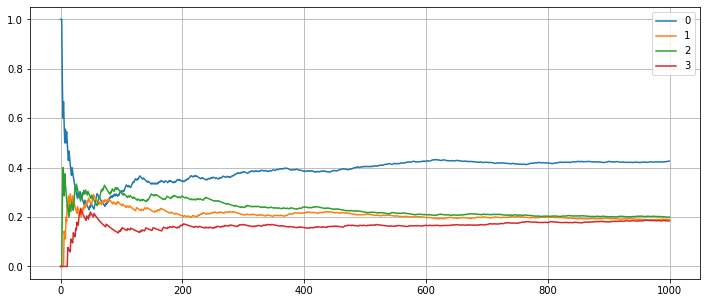

In [14]:
plt.figure(figsize=(12, 5))
for i in range(4):
    sns.lineplot(np.cumsum(winner_list == i) / (np.arange(len(reward_list)) + 1), label=f'{i}')
_ = plt.grid()

In [20]:
num_experiments=100
can_wait=True
verbose=False
reward_list = []

In [21]:
maze_names = [
    "PacMan",
    "Hypersonic",
    "Oasis",
    "Corridors",
    "OriginOfSymmetry",
    "FourOfAKind"
]

In [41]:
for i in tqdm(range(num_experiments)):
    maze_name = np.random.choice(maze_names)
#     maze_name = 'OriginOfSymmetry'
    env = KutuluWorldEnv(
        server_host='localhost:8080',
        maze_name=maze_name,
        league_level=1,
        players_count=4,
    )
    player = KutuluPlayer(env)
    observation, info = env.reset()
    np.random.shuffle(players_map)
    rollout_rewards = []
    game_over = False
    while not game_over:
        action = env.sample_valid_action(can_wait)
        
        state_actions = {}
        for env_player in env.active_players():
            player_id = env_player['id']
            game_player_id = players_map[player_id]
            if game_players[game_player_id] is None:
                continue
            _pi = game_players[game_player_id]
            state = player.get_state(player_id, max_explorer_dist=5, max_wanderer_dist=5)
            player_mask = ~np.array(player.env.get_valid_action_mask()[player_id])
            At = _pi.getActionEpsGreedyMasked(state, len(DEFAULT_KUTULU_ACTIONS), eps, player_mask)
            action[player_id] = At
            state_actions[player_id] = (state, At)

        entities, rewards, game_over, info = env.step(action)
        rollout_rewards.append(rewards)
        
        if verbose:
            viz_map(env.map, entities['entities'])

#     reward_list.append(rollout_rewards)
    rollout_rewards = np.array(rollout_rewards, dtype=float)[:,np.argsort(players_map)]
    reward_list.append(rollout_rewards)

100%|██████████| 100/100 [00:45<00:00,  2.20it/s]


In [42]:
total_reward_list = np.array([np.nansum(rewards, axis=0) for rewards in reward_list])

In [43]:
winner_list = np.argmax(total_reward_list, 1)

In [44]:
Counter(winner_list)

Counter({0: 74, 1: 43, 3: 41, 2: 42})

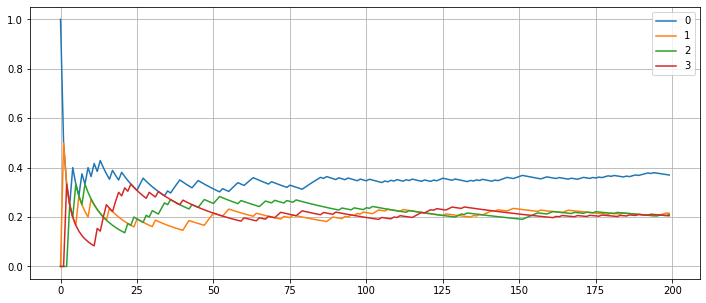

In [45]:
plt.figure(figsize=(12, 5))
for i in range(4):
    sns.lineplot(np.cumsum(winner_list == i) / (np.arange(len(reward_list)) + 1), label=f'{i}')
_ = plt.grid()

In [46]:
check_policy(Q)

0.29411764705882354

In [47]:
import pickle as pkl
import zlib
import base64

In [48]:
len([k for k in pi.Q.keys()])

1192

In [49]:
# new_keys = [k for k in pi.Q.keys() if ((k[1] or 0) < 8) and ((k[3] or 0) < 6)]
new_keys = list(pi.Q.keys())

In [50]:
len(new_keys)

1192

In [51]:
data1 = pkl.dumps(np.array(list(pi.Q[k] for k in new_keys), dtype='float16'))
data2 = pkl.dumps(list(new_keys))

In [52]:
len(base64.b64encode(zlib.compress(data1, level=9)))

15096

In [53]:
len(base64.b64encode(zlib.compress(data2, level=9)))

14508

In [54]:
model_dir = f"../output/{datetime.now()}"
date, time = model_dir.split()
os.mkdir(date, )
os.mkdir(f"{date}/{time}")
with open(f"{date}/{time}/data1.pkl", "wb") as f:
    f.write(data1)
with open(f"{date}/{time}/data2.pkl", "wb") as f:
    f.write(data2)

In [57]:
# base64.b64encode(zlib.compress(data1, level=9))